<a href="https://colab.research.google.com/github/tomeravgil/Homework5CSCI6170/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1

Dataset chosen was SVHN (Street View House Numbers)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128

# VAE needs [0,1], GAN needs [-1,1]
transform_vae = transforms.Compose([transforms.ToTensor()])
transform_gan = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,)*3, (0.5,)*3)])

train_vae = datasets.SVHN(root="./data", split="train", download=True, transform=transform_vae)
train_gan = datasets.SVHN(root="./data", split="train", download=True, transform=transform_gan)

vae_loader = DataLoader(train_vae, batch_size=BATCH_SIZE, shuffle=True)
gan_loader = DataLoader(train_gan, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 182M/182M [00:27<00:00, 6.58MB/s]


## Part 1

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(64 * 8 * 8, latent_dim)
        self.dec_fc = nn.Linear(latent_dim, 64 * 8 * 8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.dec(self.dec_fc(z).view(-1, 64, 8, 8)), mu, logvar

vae = VAE().to(DEVICE)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(10):
    for x, _ in vae_loader:
        x = x.to(DEVICE)
        recon, mu, logvar = vae(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = (recon_loss + kl_loss) / x.size(0)

        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
    print(f"VAE Epoch {epoch+1} Loss: {loss.item():.2f}")

VAE Epoch 1 Loss: 1935.68
VAE Epoch 2 Loss: 1879.63
VAE Epoch 3 Loss: 1938.91
VAE Epoch 4 Loss: 1876.55
VAE Epoch 5 Loss: 1892.70
VAE Epoch 6 Loss: 1896.07
VAE Epoch 7 Loss: 1922.03
VAE Epoch 8 Loss: 1894.68
VAE Epoch 9 Loss: 1909.21
VAE Epoch 10 Loss: 1878.07


## Part 2

In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 4, 1, 0), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 0)
        )
    def forward(self, x): return self.net(x).view(-1)

G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)
opt_G, opt_D = torch.optim.Adam(G.parameters(), 2e-4, (0.5, 0.999)), torch.optim.Adam(D.parameters(), 2e-4, (0.5, 0.999))
crit = nn.BCEWithLogitsLoss()

for epoch in range(10):
    for x, _ in gan_loader:
        b = x.size(0)
        real_x = x.to(DEVICE)

        # Train D
        z = torch.randn(b, 100, 1, 1, device=DEVICE)
        fake_x = G(z)
        loss_D = crit(D(real_x), torch.ones(b, device=DEVICE)) + crit(D(fake_x.detach()), torch.zeros(b, device=DEVICE))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # Train G
        loss_G = crit(D(fake_x), torch.ones(b, device=DEVICE))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    print(f"GAN Epoch {epoch+1} G_Loss: {loss_G.item():.2f} D_Loss: {loss_D.item():.2f}")

GAN Epoch 1 G_Loss: 4.52 D_Loss: 0.11
GAN Epoch 2 G_Loss: 5.42 D_Loss: 1.18
GAN Epoch 3 G_Loss: 3.43 D_Loss: 0.07
GAN Epoch 4 G_Loss: 3.57 D_Loss: 0.06
GAN Epoch 5 G_Loss: 2.11 D_Loss: 0.31
GAN Epoch 6 G_Loss: 5.38 D_Loss: 0.41
GAN Epoch 7 G_Loss: 3.51 D_Loss: 0.22
GAN Epoch 8 G_Loss: 7.66 D_Loss: 0.08
GAN Epoch 9 G_Loss: 4.67 D_Loss: 0.06
GAN Epoch 10 G_Loss: 4.19 D_Loss: 0.05


## Comparing Part 1 & Part 2

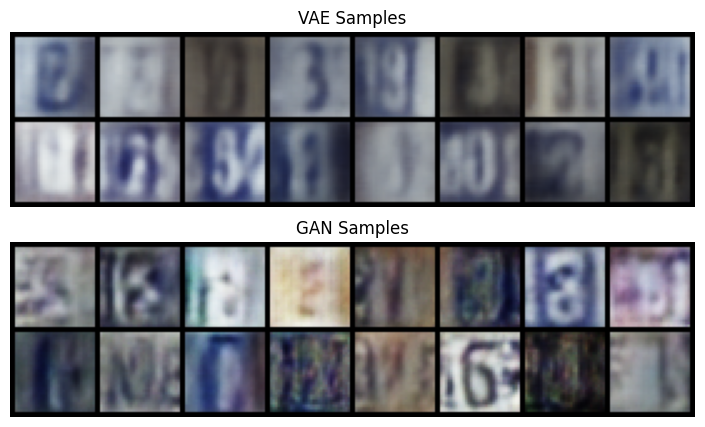

In [6]:
with torch.no_grad():
    # Sample VAE
    z_vae = torch.randn(16, 64, device=DEVICE)
    vae_samples = vae.dec(vae.dec_fc(z_vae).view(-1, 64, 8, 8)).cpu()

    # Sample GAN
    z_gan = torch.randn(16, 100, 1, 1, device=DEVICE)
    gan_samples = (G(z_gan) * 0.5 + 0.5).cpu() # Denormalize

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].imshow(make_grid(vae_samples, nrow=8).permute(1, 2, 0))
ax[0].set_title("VAE Samples"); ax[0].axis('off')
ax[1].imshow(make_grid(gan_samples, nrow=8).permute(1, 2, 0))
ax[1].set_title("GAN Samples"); ax[1].axis('off')
plt.show()

## Overall Differences

As we can see, both VAE and GAN were able to replicate results, but they are a bit blurry. In the case specificed, it is noticable that GAN results are less blurry than VAE's. This is mainly because the VAE model uses a pixel wise reconstruction loss and when the model is not 100% sure where a edge should be, the safest way to minimize its loss would be to average all the possible positions. This gives a blurry apperance as is shown. The GAN takes a different approach with a discriminator acting as a critic. If an image is blurry the discriminator identifies it as fake so the generator is forced to produce sharp edges and high contract features that look like real numbers, but it can miss the exact structure of a digit.